In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('fifa_world_cup_2026_player_performance.csv')
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [ ]:
df.shape

(10929, 75)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10929 entries, 0 to 10928
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 10929 non-null  object 
 1   player_name               10929 non-null  object 
 2   age                       10929 non-null  int64  
 3   nationality               10929 non-null  object 
 4   team                      10929 non-null  object 
 5   jersey_number             10929 non-null  int64  
 6   position                  10929 non-null  object 
 7   height_cm                 10929 non-null  int64  
 8   weight_kg                 10929 non-null  int64  
 9   preferred_foot            10929 non-null  object 
 10  club_name                 10929 non-null  object 
 11  market_value_eur          10929 non-null  int64  
 12  match_id                  10929 non-null  object 
 13  match_date                10929 non-null  object 
 14  stadiu

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
player_id,0
player_name,0
age,0
nationality,0
team,0
...,...
total_goals_tournament,0
total_assists_tournament,0
total_minutes_tournament,0
player_of_match_awards,0


In [ ]:
df.columns

Index(['player_id', 'player_name', 'age', 'nationality', 'team',
       'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot',
       'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_k

In [ ]:
df['match_date'] = pd.to_datetime(df['match_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10929 entries, 0 to 10928
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   player_id                 10929 non-null  object        
 1   player_name               10929 non-null  object        
 2   age                       10929 non-null  int64         
 3   nationality               10929 non-null  object        
 4   team                      10929 non-null  object        
 5   jersey_number             10929 non-null  int64         
 6   position                  10929 non-null  object        
 7   height_cm                 10929 non-null  int64         
 8   weight_kg                 10929 non-null  int64         
 9   preferred_foot            10929 non-null  object        
 10  club_name                 10929 non-null  object        
 11  market_value_eur          10929 non-null  int64         
 12  match_id          

In [ ]:
clean_df = df.copy()
clean_df.head(3)

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4


In [ ]:
#Create New Date Features

clean_df["year"] = clean_df["match_date"].dt.year
clean_df["month"] = clean_df["match_date"].dt.month
clean_df["day"] = clean_df["match_date"].dt.day
clean_df["day_name"] = clean_df["match_date"].dt.day_name()
clean_df.shape

(10929, 79)

In [ ]:
#Standardize Text Columns
#Convert text columns to remove unwanted spaces

text_columns = clean_df.select_dtypes(include="object").columns
for col in text_columns:
    clean_df[col] = clean_df[col].str.strip()

In [ ]:
# Check Columns Names

clean_df.columns

Index(['player_id', 'player_name', 'age', 'nationality', 'team',
       'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot',
       'club_name', 'market_value', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'xg', 'xa', 'key_passes',
       'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh',
       'accelerations', 'decele

In [ ]:
#Rename Columns (Optional)
#If you prefer shorter names.

clean_df.rename(columns={
    "market_value_eur": "market_value",
    "expected_goals_xg": "xg",
    "expected_assists_xa": "xa"
}, inplace=True)

In [ ]:
 #Final Shape

print("Final Dataset Shape :", clean_df.shape)

Final Dataset Shape : (10929, 79)


In [ ]:
#Handle Missing Values

#Numerical Columns

# Get numerical columns

num_cols = clean_df.select_dtypes(include=np.number).columns

# Fill missing numerical values with median

for col in num_cols:
   clean_df[num_cols].fillna(
    clean_df[num_cols].median(), inplace=True
)


In [ ]:
#Categorical Columns

# Get categorical columns

cat_cols = clean_df.select_dtypes(include="object").columns

# Fill missing categorical values with mode

for col in cat_cols:
    clean_df[col].fillna(
        clean_df[col].mode()[0],
        inplace=True
    )

## Univariate Analysis

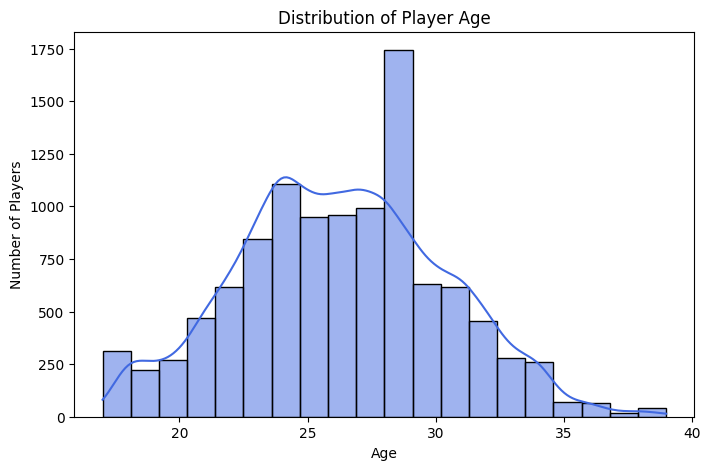

In [ ]:
#Distribution of Player Age

plt.figure(figsize=(8,5))

sns.histplot(
    data=clean_df,
    x="age",
    bins=20,
    kde=True
, color = "royalblue")

plt.title("Distribution of Player Age")
plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.show()


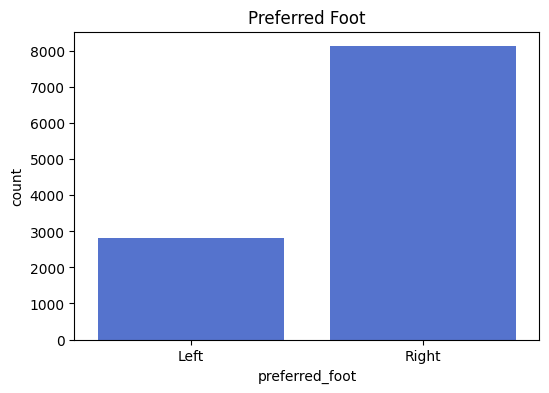

In [ ]:
 #Preferred Foot Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=clean_df,
    x="preferred_foot"
, color = 'royalblue')

plt.title("Preferred Foot")
plt.show()

Text(0.5, 1.0, 'Match Result Distribution')

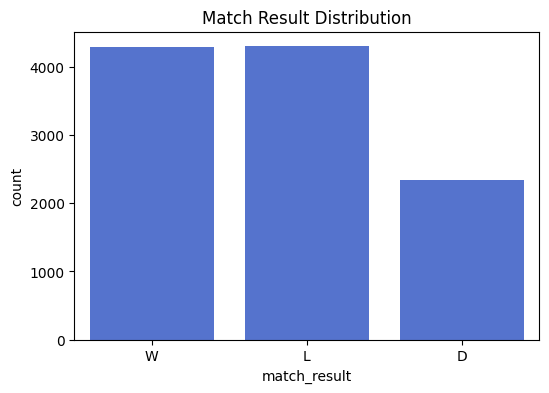

In [ ]:
 #Match Result Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=clean_df,
    x="match_result"
, color  = 'royalblue' )

plt.title("Match Result Distribution")

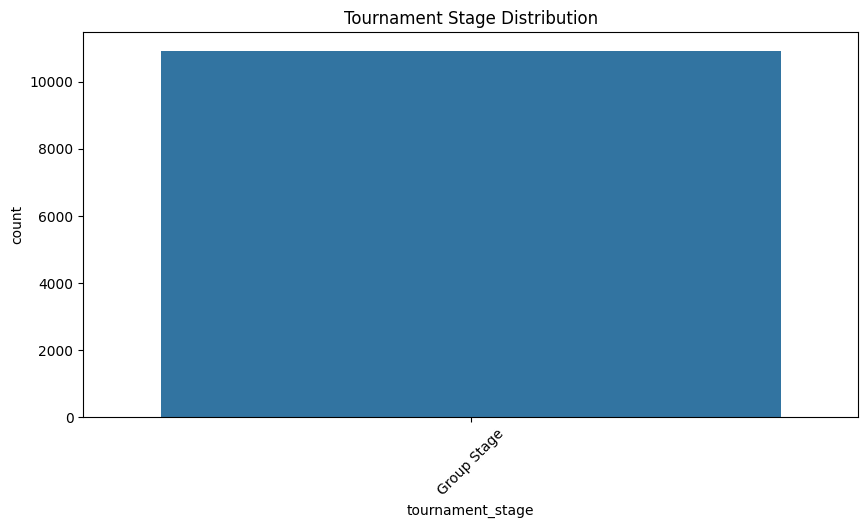

In [ ]:
#Tournament Stage Distribution

plt.figure(figsize=(10,5))

sns.countplot(
    data=clean_df,
    x="tournament_stage",
    order=clean_df["tournament_stage"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Tournament Stage Distribution")

plt.show()



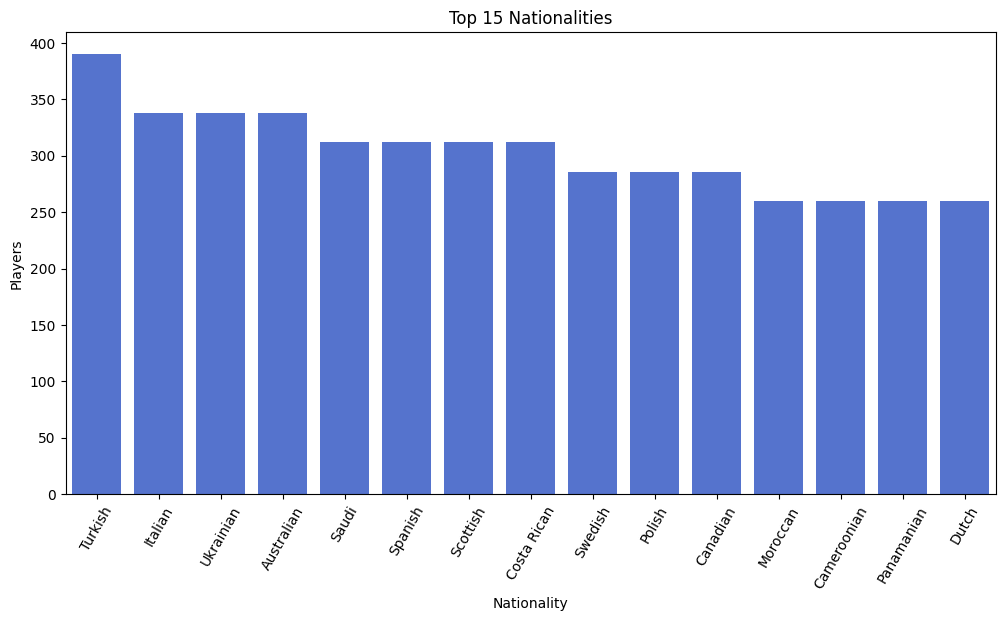

In [ ]:
# Nationality Distribution (Top 15)
top_nations = clean_df["nationality"].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_nations.index,
    y=top_nations.values,
    color='royalblue'
)
plt.xticks(rotation=60)
plt.title("Top 15 Nationalities")
plt.xlabel("Nationality")
plt.ylabel("Players")
plt.show()

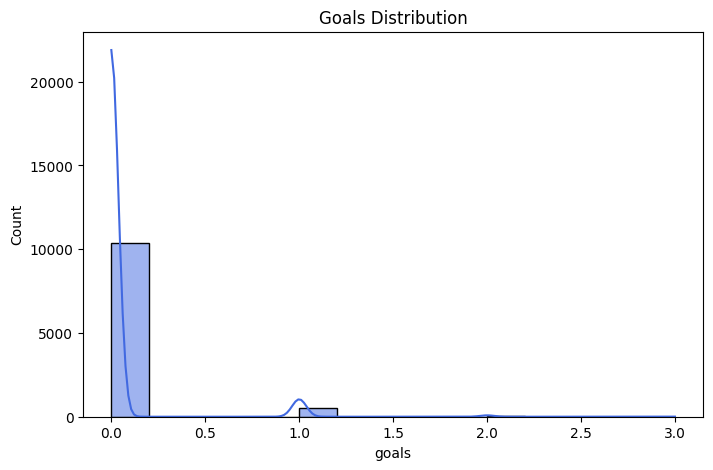

In [ ]:
#Goals Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    clean_df["goals"],
    bins=15,
    kde=True
, color = 'royalblue')

plt.title("Goals Distribution")

plt.show()

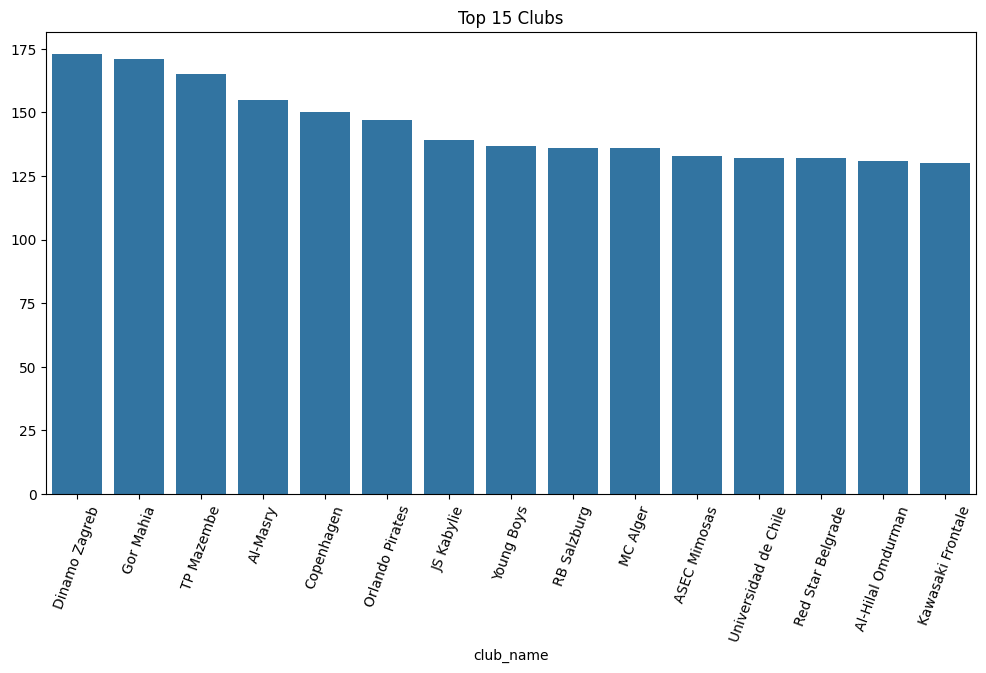

In [ ]:
#Top 15 Clubs

top_clubs = clean_df["club_name"].value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_clubs.index,
    y=top_clubs.values
)

plt.xticks(rotation=70)

plt.title("Top 15 Clubs")

plt.show()

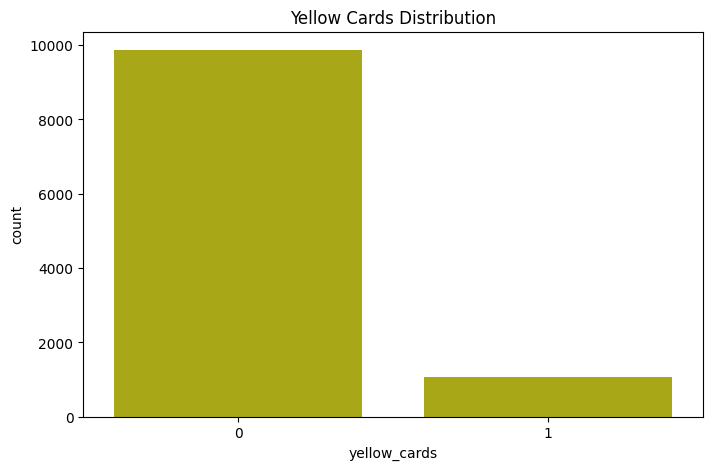

In [ ]:
#Yellow Cards Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=clean_df,
    x="yellow_cards"
, color = 'y')

plt.title("Yellow Cards Distribution")

plt.show()


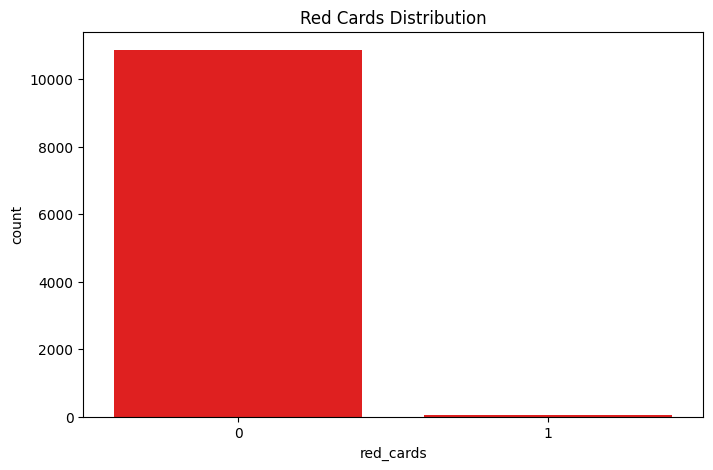

In [ ]:
#Red Cards Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=clean_df,
    x="red_cards"
, color = 'r')

plt.title("Red Cards Distribution")

plt.show()

## Bivariate Analysis

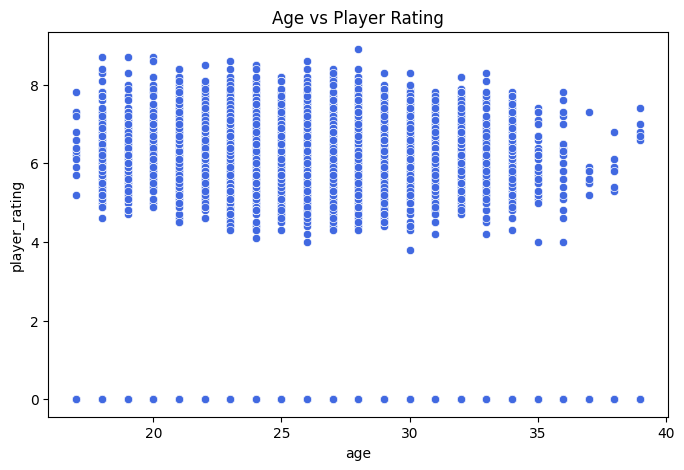

In [ ]:
#Age vs Player Rating

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=clean_df,
    x="age",
    y="player_rating", color = 'royalblue'
)

plt.title("Age vs Player Rating")

plt.show()

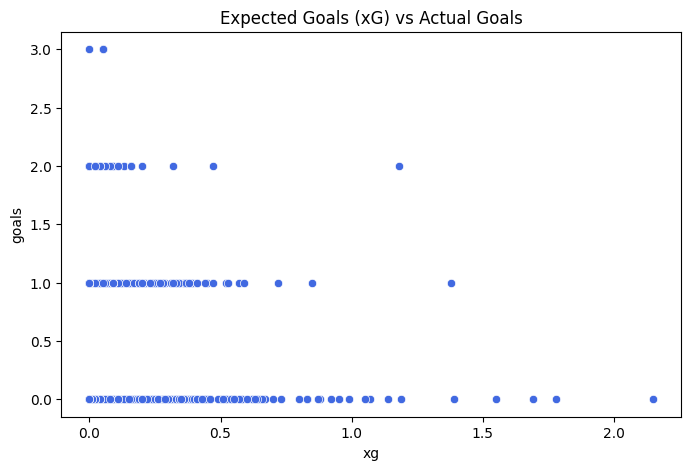

In [ ]:
#Expected Goals (xG) vs Actual Goals

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=clean_df,
    x="xg",
    y="goals", color = 'royalblue'
)

plt.title("Expected Goals (xG) vs Actual Goals")

plt.show()

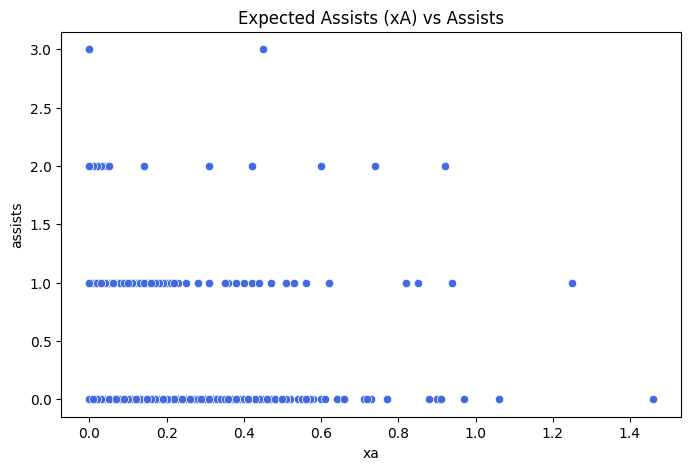

In [ ]:
#Expected Assists (xA) vs Assists

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=clean_df,
    x="xa",
    y="assists"
, color = 'royalblue')

plt.title("Expected Assists (xA) vs Assists")

plt.show()

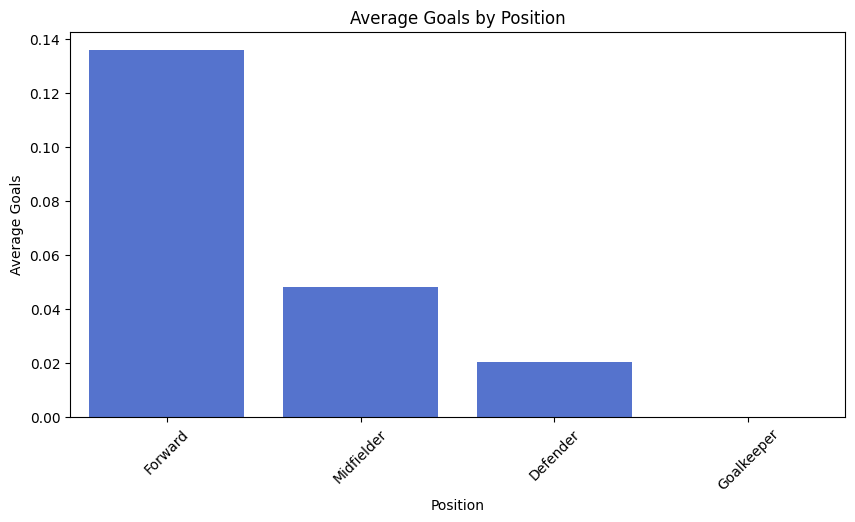

In [ ]:
#Average Goals by Position

goal_position = clean_df.groupby("position")["goals"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    x=goal_position.index,
    y=goal_position.values
, color = 'royalblue')

plt.xticks(rotation=45)

plt.title("Average Goals by Position")

plt.xlabel("Position")
plt.ylabel("Average Goals")

plt.show()

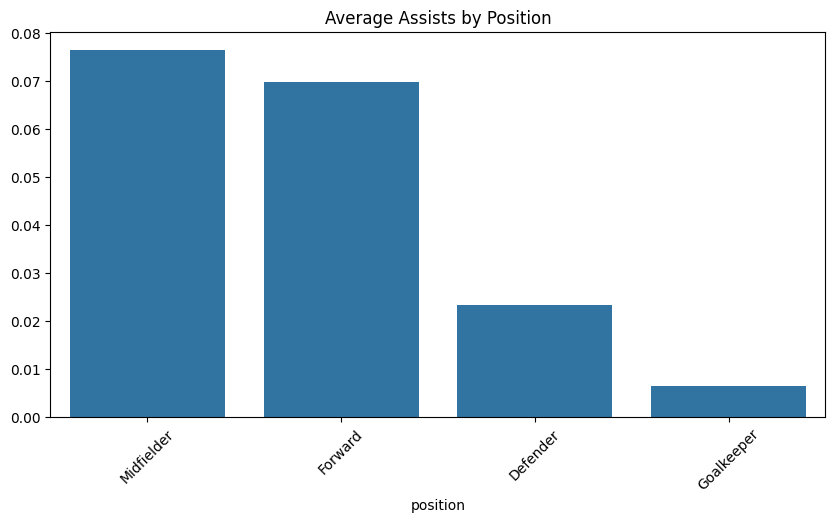

In [ ]:
#Average Assists by Position

assist_position = clean_df.groupby("position")["assists"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    x=assist_position.index,
    y=assist_position.values
)

plt.xticks(rotation=45)

plt.title("Average Assists by Position")

plt.show()

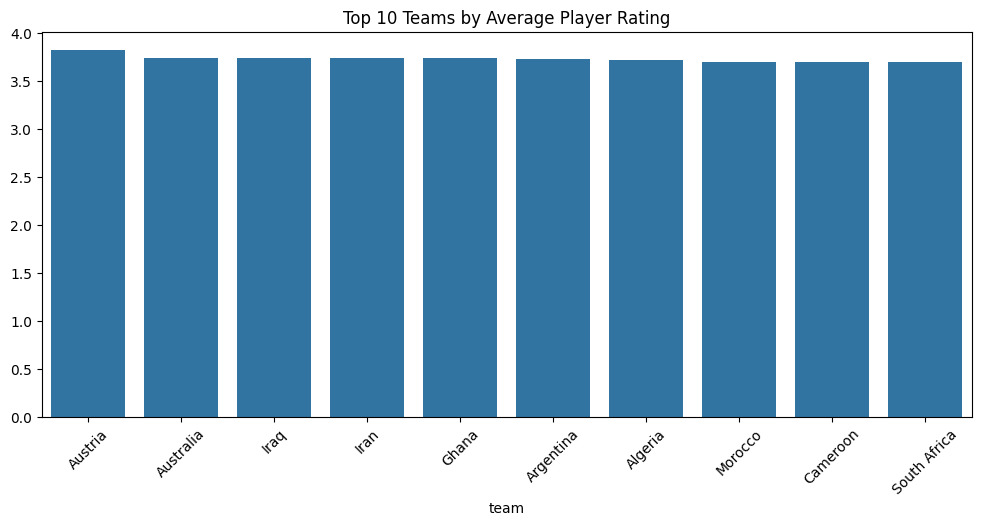

In [ ]:
#Top 10 Teams by Average Player Rating

team_rating = (
    clean_df
    .groupby("team")["player_rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=team_rating.index,
    y=team_rating.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Teams by Average Player Rating")

plt.show()

#Advanced Analysis, Business Insights & Conclusion

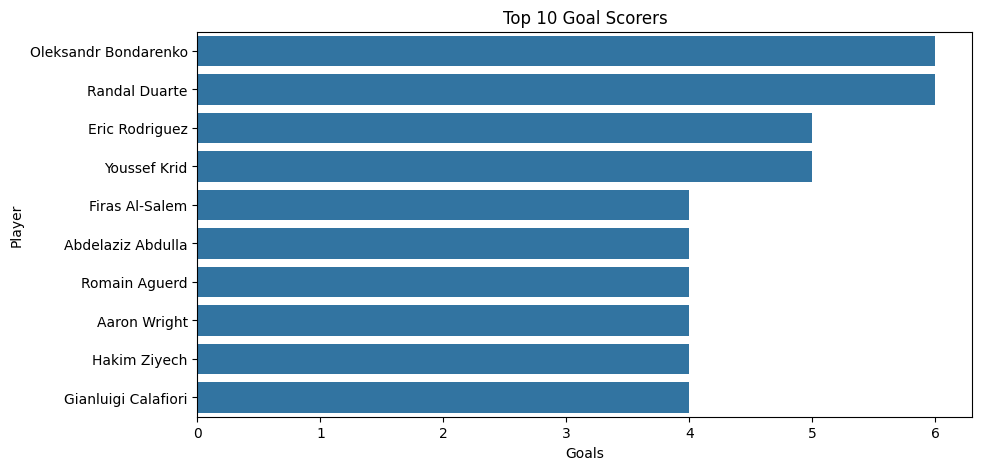

In [ ]:
#Top 10 Players by Goals

top_goals = (
    clean_df.groupby("player_name")["goals"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_goals.values,
    y=top_goals.index
)

plt.title("Top 10 Goal Scorers")
plt.xlabel("Goals")
plt.ylabel("Player")

plt.show()

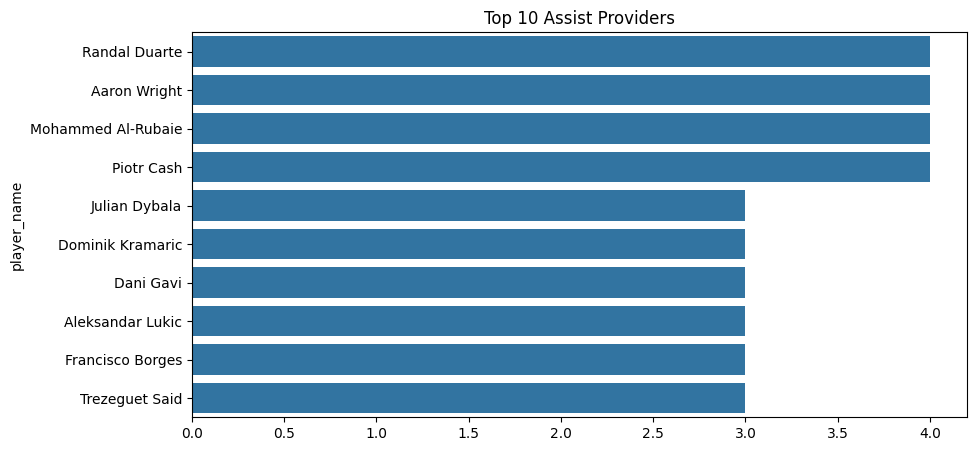

In [ ]:
#Top 10 Players by Assists

top_assists = (
    clean_df.groupby("player_name")["assists"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_assists.values,
    y=top_assists.index
)

plt.title("Top 10 Assist Providers")

plt.show()

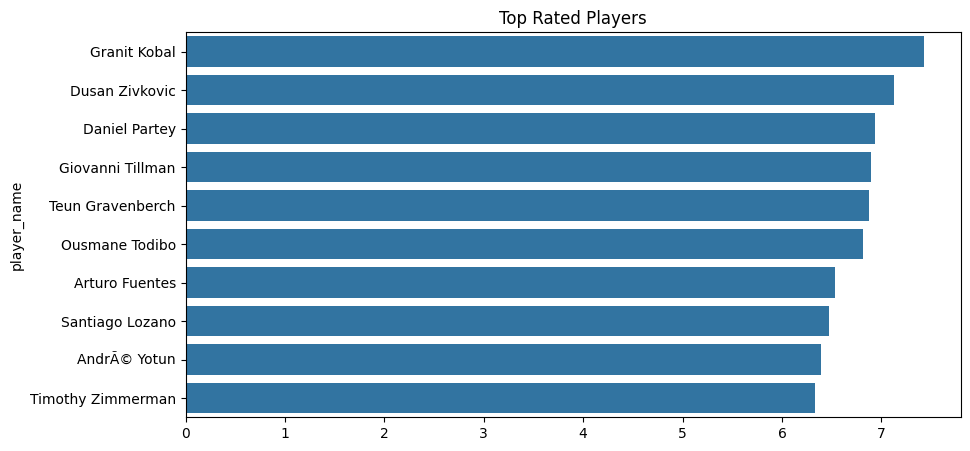

In [ ]:
#Top Rated Players

top_rating = (
    clean_df.groupby("player_name")["player_rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_rating.values,
    y=top_rating.index
)

plt.title("Top Rated Players")

plt.show()

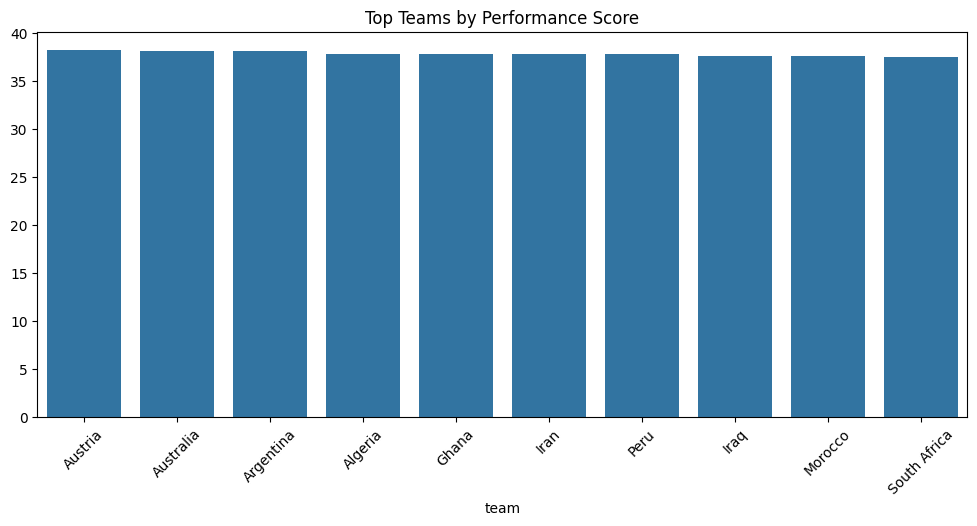

In [ ]:
#Best Teams by Average Performance Score

team_perf = (
    clean_df.groupby("team")["performance_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=team_perf.index,
    y=team_perf.values
)

plt.xticks(rotation=45)

plt.title("Top Teams by Performance Score")

plt.show()

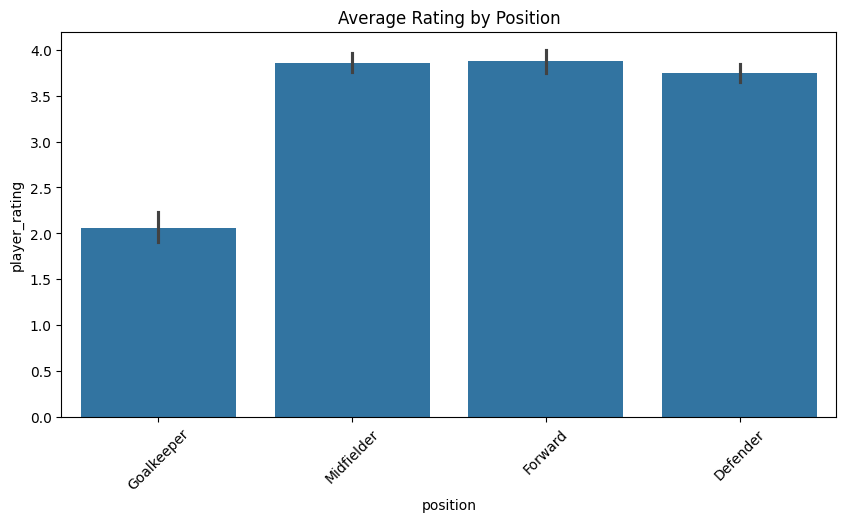

In [ ]:
#Average Rating by Position

plt.figure(figsize=(10,5))

sns.barplot(
    data=clean_df,
    x="position",
    y="player_rating",
    estimator="mean"
)

plt.xticks(rotation=45)

plt.title("Average Rating by Position")

plt.show()

In [ ]:
#Pivot Table

pivot = pd.pivot_table(
    clean_df,
    values="player_rating",
    index="position",
    columns="preferred_foot",
    aggfunc="mean"
)

pivot

preferred_foot,Left,Right
position,,
Defender,3.609231,3.809117
Forward,4.006967,3.835422
Goalkeeper,2.129703,2.038831
Midfielder,3.855123,3.865882


In [ ]:
#top 15 Players by Performance Score

clean_df.nlargest(
    15,
    "performance_score"
)[
    [
        "player_name",
        "team",
        "position",
        "goals",
        "assists",
        "player_rating",
        "performance_score"
    ]
]

,player_name,team,position,goals,assists,player_rating,performance_score
3928,Lorenzo Frascati,Italy,Defender,0,1,8.7,92.7
8925,Houssem Mokrani,Algeria,Midfielder,0,0,8.5,89.9
7288,Hakim Ezzalzouli,Morocco,Defender,0,0,8.4,89.6
7472,Rasmus Wind,Denmark,Forward,1,1,8.7,89.3
1419,Ahmed Abdallah,Egypt,Defender,0,0,8.4,89.2
9339,Hidajat Ghoddos,Iran,Forward,0,0,8.5,89.1
7079,Bryan Leiton,Costa Rica,Midfielder,0,0,8.4,88.4
4357,Keanu Duke,Australia,Forward,1,0,8.0,88.3
8297,Jose Cavani,Uruguay,Forward,0,0,8.1,88.2
8099,Mohannad Majeed,Iraq,Forward,0,0,8.4,87.9
